In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
#read csv

fuel = pd.read_csv('FuelConsumption.csv')
fuel.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [12]:
print(fuel.shape)
#print(fuel.describe())
print(fuel.columns)
#print(fuel.dtypes)


(1067, 13)
Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')


In [11]:
#categorial data understanding
print(fuel['MAKE'].unique())

# #SPACE FOR BETTER VISUALIZATION
# print(fuel['MODEL'].unique())
# print(fuel['VEHICLECLASS'].unique())
# print(fuel['TRANSMISSION'].unique())


['ACURA' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK' 'CADILLAC'
 'CHEVROLET' 'CHRYSLER' 'DODGE' 'FIAT' 'FORD' 'GMC' 'HONDA' 'HYUNDAI'
 'INFINITI' 'JAGUAR' 'JEEP' 'KIA' 'LAMBORGHINI' 'LAND ROVER' 'LEXUS'
 'LINCOLN' 'MASERATI' 'MAZDA' 'MERCEDES-BENZ' 'MINI' 'MITSUBISHI' 'NISSAN'
 'PORSCHE' 'RAM' 'ROLLS-ROYCE' 'SCION' 'SMART' 'SRT' 'SUBARU' 'TOYOTA'
 'VOLKSWAGEN' 'VOLVO']


In [13]:
# selecting features for regression model
# we will use 'CYLINDERS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB' as independent variables and 'CO2EMISSIONS' as dependent variable
fuel_subset = fuel[['CYLINDERS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
fuel_subset.head()

,CYLINDERS,ENGINESIZE,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,4,2.0,8.5,196
1,4,2.4,9.6,221
2,4,1.5,5.9,136
3,6,3.5,11.1,255
4,6,3.5,10.6,244


## Transformation.
### Why do we do transformation
1. Because most of the distribution are assumed to be ***Normally distributed***

- You can only use  ***log*** transformation if the values are positive.

- Same applies for ***square root***

- While ***sine*** works for all, both positive and negative

### Visualization
2. Afer transformation, visualize with a ***histogram*** to know if our data is normally distributed.


# 1. Histogram
- 

array([[<Axes: title={'center': 'CYLINDERS'}>,
        <Axes: title={'center': 'ENGINESIZE'}>],
       [<Axes: title={'center': 'FUELCONSUMPTION_COMB'}>,
        <Axes: title={'center': 'CO2EMISSIONS'}>]], dtype=object)

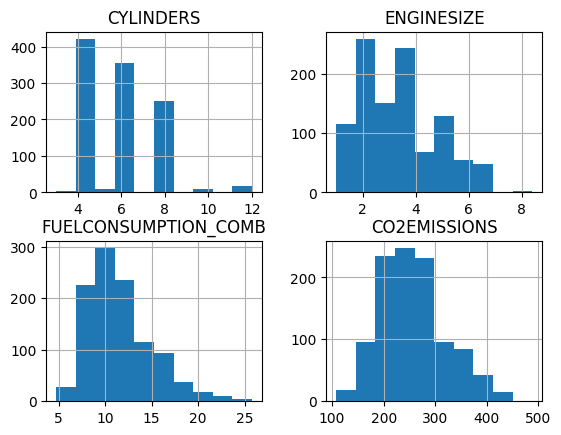

In [14]:
# Histograms of our subset of data
fuel_subset.hist()

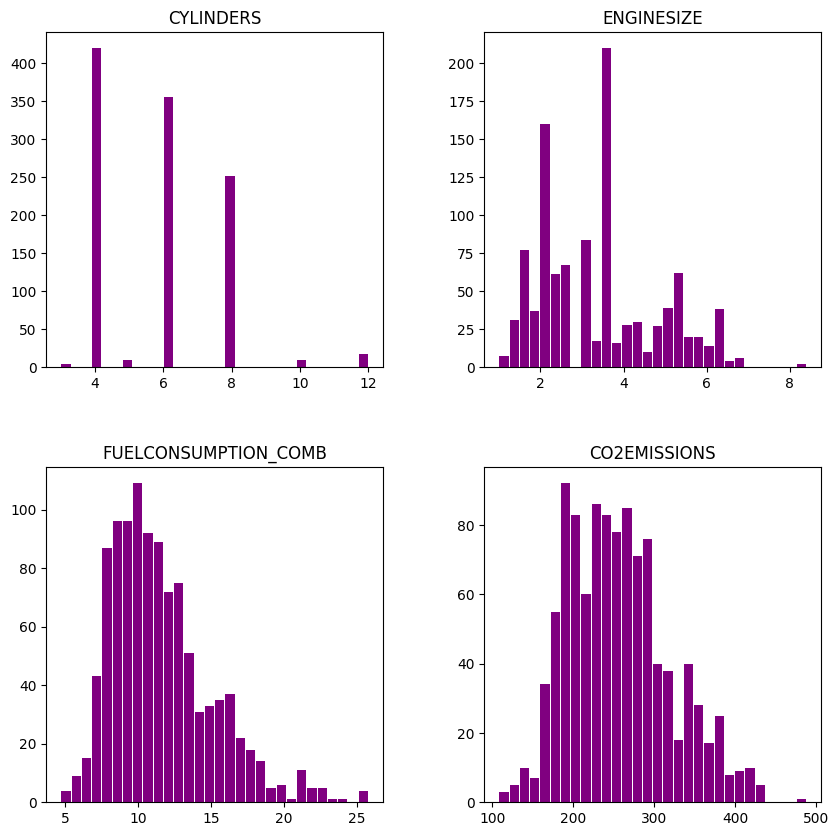

In [22]:
# plit histogram with ggplot, each in its frame, with grid and 30 bins, color purple, zorder 2 and rwidth 0.9
fuel_subset.hist(figsize=(10,10), grid=False, bins=30, color='purple', zorder=2, rwidth=0.9)
plt.show()

# 2. Density Plot

- This is used to 

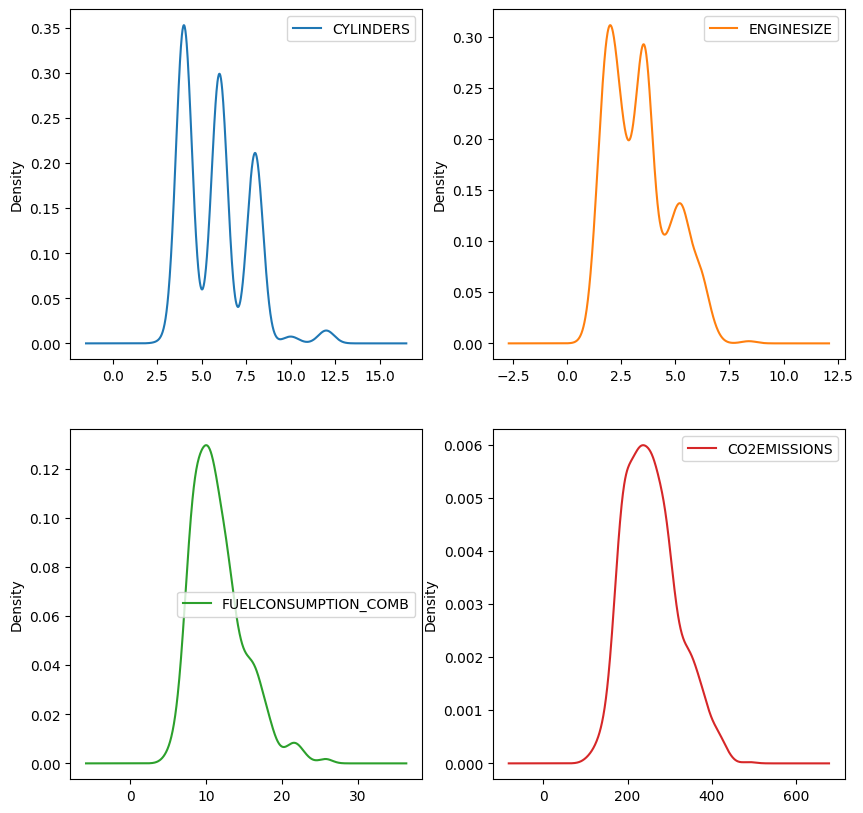

In [31]:
# density plot on one frame
fuel_subset.plot(kind='density', subplots=True, layout=(2,2), sharex=False, figsize=(10,10))
plt.show()

# 3. Scatter plot.
- This tells us if the data is linear or not.

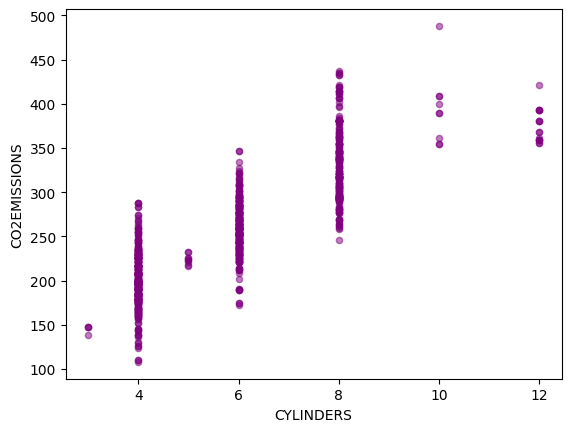

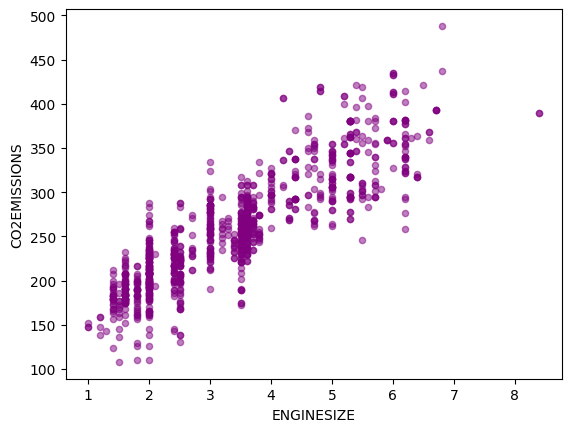

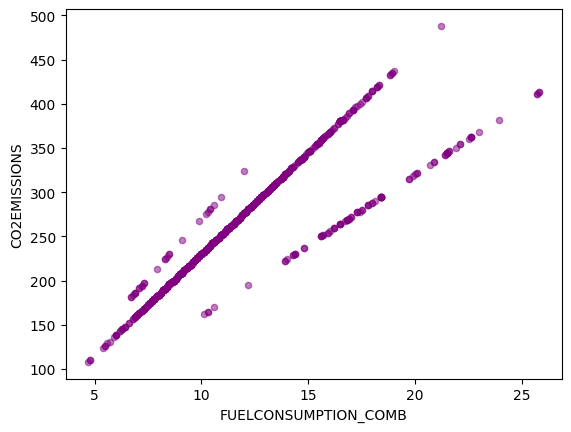

In [34]:
# Plot scatteplot of subset in one frame with subheadings, color purple and alpha 0.5
fuel_subset.plot(kind='scatter', x='CYLINDERS', y='CO2EMISSIONS', color='purple', alpha=0.5)
fuel_subset.plot(kind='scatter', x='ENGINESIZE', y='CO2EMISSIONS', color='purple', alpha=0.5)
fuel_subset.plot(kind='scatter', x='FUELCONSUMPTION_COMB', y='CO2EMISSIONS', color='purple', alpha=0.5)
plt.show()

In [51]:
# Train test split (80% train, 20% test)
# This helps us to evaluate the performance of our model on unseen data

msk = np.random.rand(len(fuel_subset)) < 0.8
train = fuel_subset[msk]
test = fuel_subset[~msk]
print(train.shape)
print(test.shape)

(831, 4)
(236, 4)


In [52]:
# train test split with seed for reproducibility
# this ensures that we get the same train and test split every time we run the code

np.random.seed(123)
msk = np.random.rand(len(fuel_subset)) < 0.8
train = fuel_subset[msk]
test = fuel_subset[~msk]
print(train.shape)
print(test.shape)

(858, 4)
(209, 4)


# A. ***Simple Linear Regression***

In [58]:
#fit the model\
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(train_x, train_y)
print('Coefficients: ', regr.coef_)


Coefficients:  [[38.18890709]]


In [59]:
# show coeficient, r2 score, residuals and mean absolute error
from sklearn.metrics import r2_score, mean_absolute_error
test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_pred = regr.predict(test_x)
print('R2 score: ', r2_score(test_y, test_y_pred))
print('Mean absolute error: ', mean_absolute_error(test_y, test_y_pred))        

R2 score:  0.7968573376213632
Mean absolute error:  23.563012376667288


- 0.86% of the data is explained by the model.

- i.e the other variables are the ones scattered on the plot

In [60]:
# adjusted r2 score
n = test_x.shape[0] # number of samples
p = test_x.shape[1] # number of features
adjusted_r2 = 1 - (1 - r2_score(test_y, test_y_pred)) * (n - 1) / (n - p - 1)
print('Adjusted R2 score: ', adjusted_r2)

Adjusted R2 score:  0.7958759721026258


- p-value: is the model a good fit for your dataset or not?

Text(0, 0.5, 'Residuals')

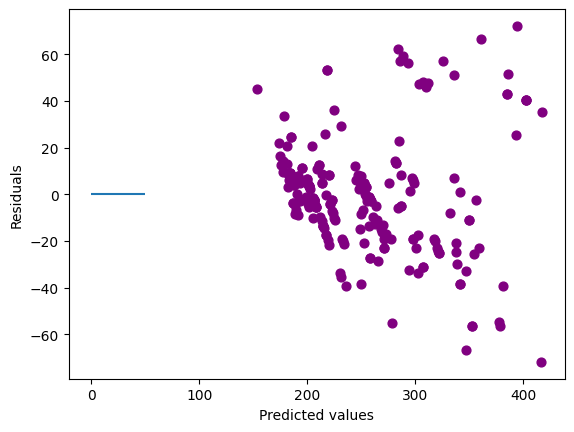

In [55]:
# residuals plot
plt.scatter(test_y_pred, test_y_pred - test_y, color='purple', s=40)
plt.hlines(y=0, xmin=0, xmax=50)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

In [61]:
# give better model summary with statsmodels
import statsmodels.api as sm
X = train[['ENGINESIZE']]
Y = train['CO2EMISSIONS']
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print(model.summary())      

                            OLS Regression Results                            
Dep. Variable:           CO2EMISSIONS   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     2621.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          8.89e-263
Time:                        19:06:51   Log-Likelihood:                -4159.1
No. Observations:                 858   AIC:                             8322.
Df Residuals:                     856   BIC:                             8332.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        127.6543      2.724     46.867      0.0

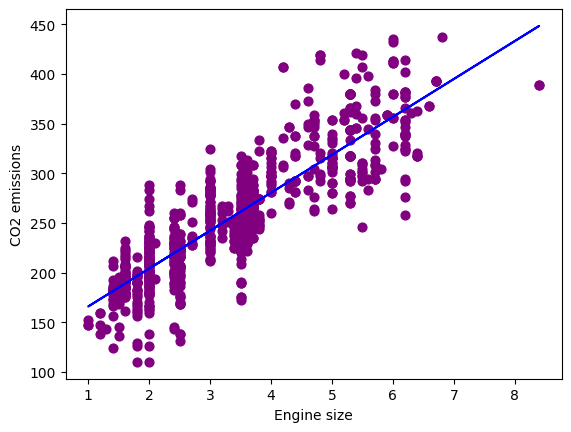

In [62]:
#Plot regression line
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='purple', s=40)
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], color='blue')
plt.xlabel('Engine size')
plt.ylabel('CO2 emissions')
plt.show()

In [68]:
# Make predictions on test data and add it as last column to test dataframe
test_y_pred = regr.predict(test_x)
test['PREDICTED_CO2EMISSIONS'] = test_y_pred
test.head()

,CYLINDERS,ENGINESIZE,FUELCONSUMPTION_COMB,CO2EMISSIONS,PREDICTED_CO2EMISSIONS
6,6,3.5,10.1,232,261.315520
21,4,2.0,9.3,214,204.032160
37,4,2.0,10.5,242,204.032160
38,4,2.0,10.4,239,204.032160
44,8,4.2,14.6,336,288.047755


In [70]:
# Evaluate model performance with R2 score, mean absolute error and adjusted R2 score and RMSE as a table
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, test_y_pred))
performance = pd.DataFrame({'R2 Score': [r2_score(test_y, test_y_pred)],
                            'Adjusted R2 Score': [adjusted_r2],
                            'Mean Absolute Error': [mean_absolute_error(test_y, test_y_pred)],
                            'RMSE': [rmse]})
print(performance)


   R2 Score  Adjusted R2 Score  Mean Absolute Error       RMSE
0  0.796857           0.795876            23.563012  30.674065


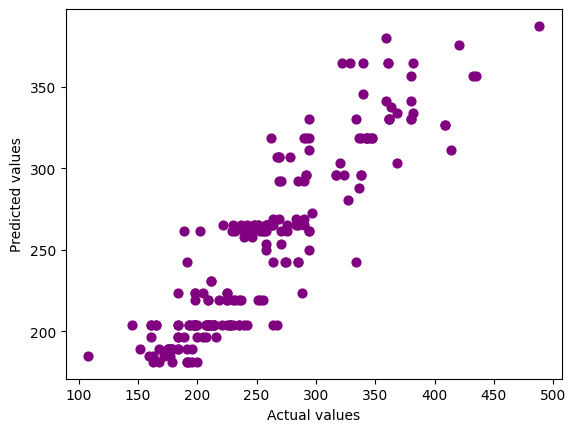

In [71]:
# Plot actual vs predicted values
plt.scatter(test_y, test_y_pred, color='purple', s=40)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()


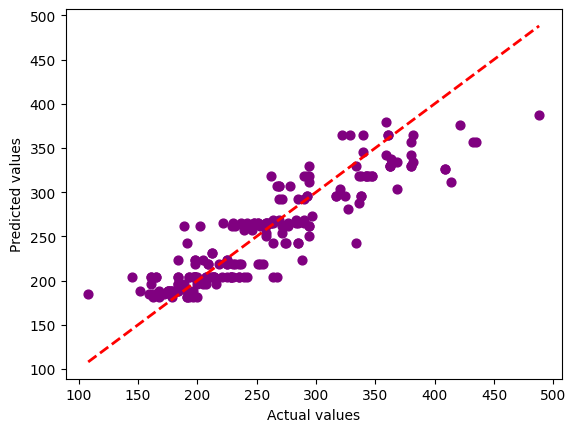

In [77]:
# Plot actual vs predicted with line y=x
plt.scatter(test_y, test_y_pred, color='purple', s=40)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], color='red', lw=2, linestyle='--', label='Best Fit')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()

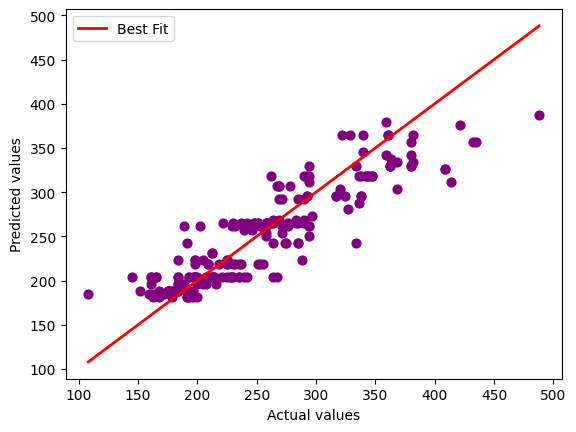

In [76]:
# Plot actual vs predicted with line labeled as best fit
plt.scatter(test_y, test_y_pred, color='purple', s=40)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], color='red', lw=2, label= 'Best Fit')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()
plt.show()

# B. ***Multiple Linear Regression***

In [78]:
# Split data into 80% train and 20% test with seed for reproducibility for multiple linear regression (ie more than one independent variable)
np.random.seed(123)
msk = np.random.rand(len(fuel_subset)) < 0.8
train = fuel_subset[msk]
test = fuel_subset[~msk]
print(train.shape)
print(test.shape)

(858, 4)
(209, 4)


In [79]:
# Fit the model, engine and fuel consumption
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE', 'FUELCONSUMPTION_COMB']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(train_x, train_y)
print('Coefficients: ', regr.coef_)


Coefficients:  [[18.50049125  9.99758979]]


In [80]:
# give better model summary with statsmodels
import statsmodels.api as sm
X = train[['ENGINESIZE', 'FUELCONSUMPTION_COMB']]
Y = train['CO2EMISSIONS']
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print(model.summary())      

                            OLS Regression Results                            
Dep. Variable:           CO2EMISSIONS   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     2535.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:52:02   Log-Likelihood:                -3930.0
No. Observations:                 858   AIC:                             7866.
Df Residuals:                     855   BIC:                             7880.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   78.4535 

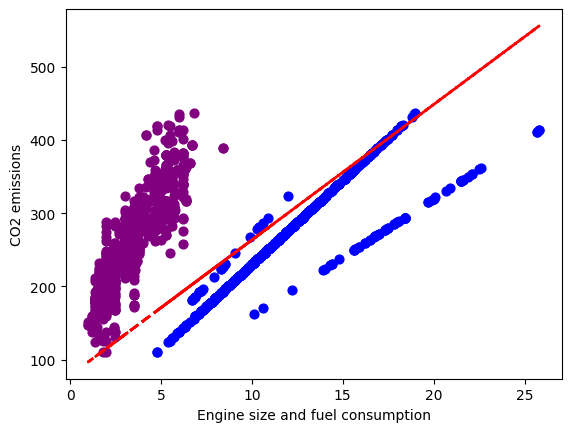

In [90]:
# Plot regression line for multiple linear regression show the line for each independent variable
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='purple', s=40)
plt.scatter(train.FUELCONSUMPTION_COMB, train.CO2EMISSIONS, color='blue', s=40)
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], color='red', lw=2, linestyle='--')
plt.xlabel('Engine size and fuel consumption')
plt.ylabel('CO2 emissions')
plt.show()


In [83]:
# Make predictions on test data and add it as last column to test dataframe
test_x = np.asanyarray(test[['ENGINESIZE', 'FUELCONSUMPTION_COMB']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_pred = regr.predict(test_x)
test['PREDICTED_CO2EMISSIONS'] = test_y_pred
test.head()

,CYLINDERS,ENGINESIZE,FUELCONSUMPTION_COMB,CO2EMISSIONS,PREDICTED_CO2EMISSIONS
6,6,3.5,10.1,232,244.180897
21,4,2.0,9.3,214,208.432088
37,4,2.0,10.5,242,220.429196
38,4,2.0,10.4,239,219.429437
44,8,4.2,14.6,336,302.120395


In [84]:
# Evaluate model performance with R2 score, mean absolute error and adjusted R2 score and RMSE as a table
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, test_y_pred))
performance = pd.DataFrame({'R2 Score': [r2_score(test_y, test_y_pred)],
                            'Adjusted R2 Score': [adjusted_r2],
                            'Mean Absolute Error': [mean_absolute_error(test_y, test_y_pred)],
                            'RMSE': [rmse]})
print(performance)

   R2 Score  Adjusted R2 Score  Mean Absolute Error       RMSE
0  0.866011           0.795876            18.122833  24.911855


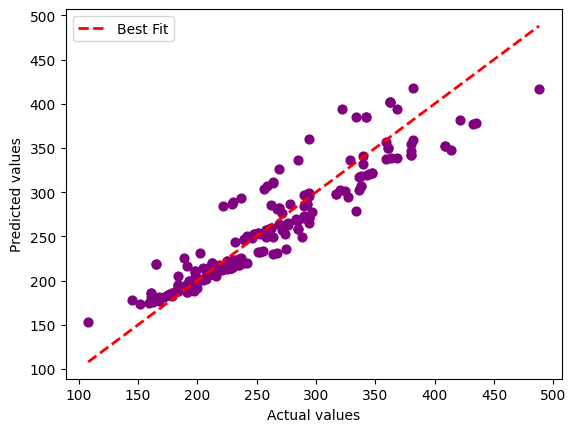

In [87]:
# Plot actual vs predicted with line labeled as best fit
plt.scatter(test_y, test_y_pred, color='purple', s=40)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], color='red', lw=2, linestyle='--', label= 'Best Fit')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()
plt.show()